# Method 1: Calculate Wavelength Shift from Hg Spectrum

# 1. Load Reference Hg Spectrum from Lab L0 file

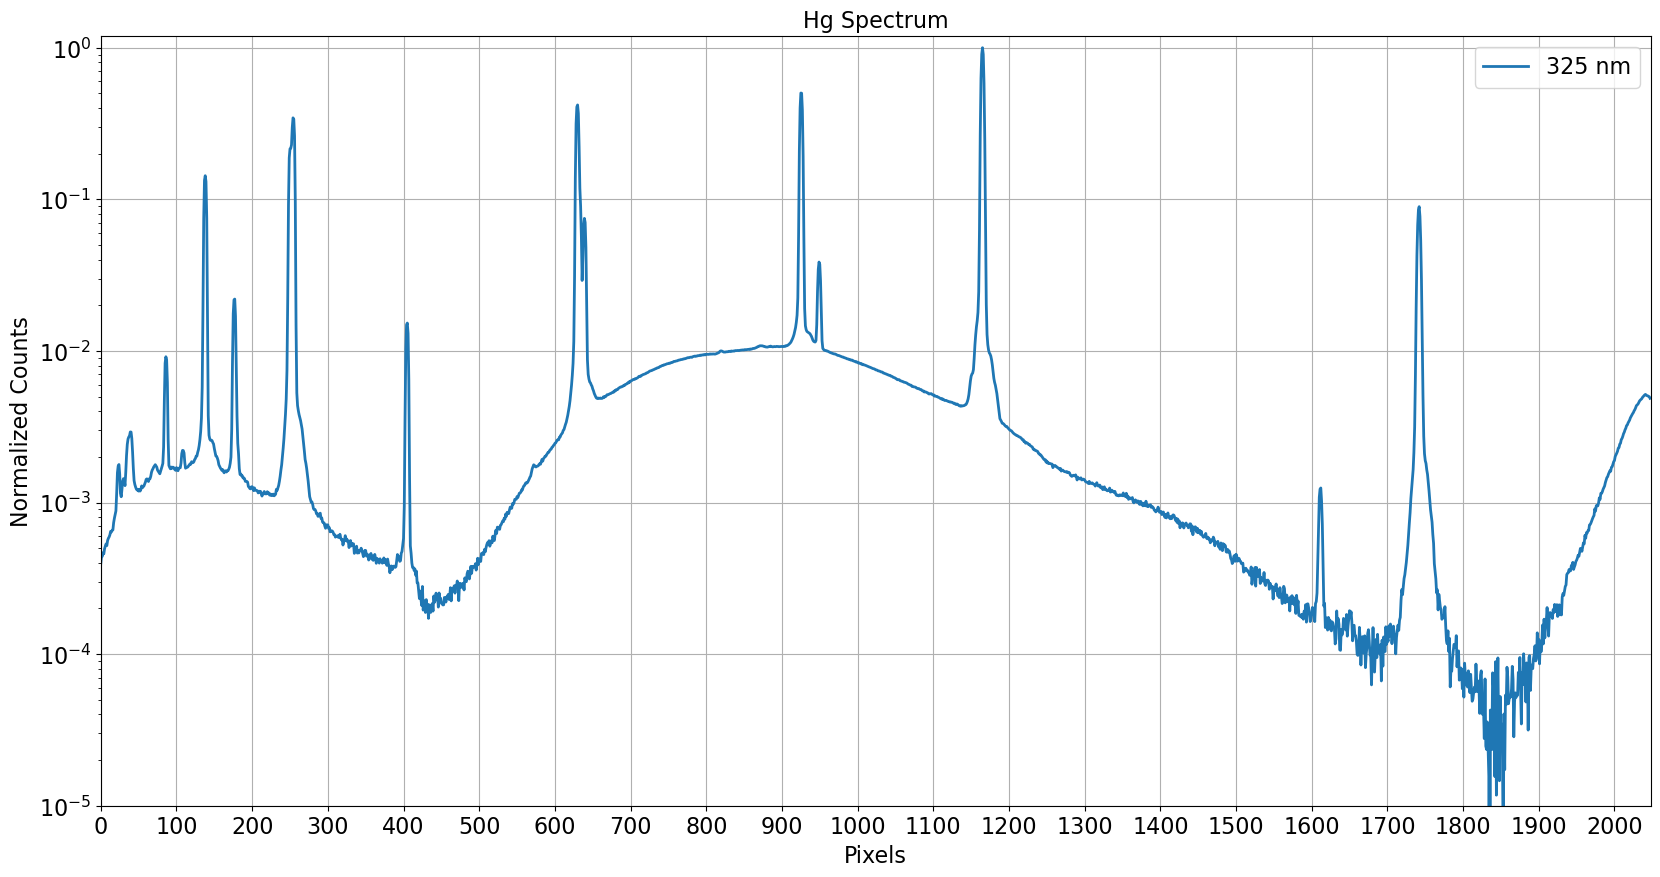

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def normalize(data):
    data = np.asarray(data, dtype=float)
    n = (data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data))
    return n


file_path = r"C:\Users\sciglob\OneDrive - UMBC\4. SciGlob\code\wavelength_shift_calculation\calibration_files\Pandora2s1_LabGSFC_20210909_L0.txt"

base_name = os.path.basename(file_path)
csv_file_name = os.path.splitext(base_name)[0] + '.csv'

# Read the entire file
with open(file_path, 'r', encoding='latin1') as file:
    lines = file.readlines()

data_lines = lines[43:]

# Process each line to split into rows and columns
data_list = []
for line in data_lines:
    # Strip the newline character and split by tabs
    rows = line.strip().split('\t')
    for row in rows:
        # Split each row by spaces
        columns = row.split()
        data_list.append(columns)

# Convert the list of lists into a DataFrame
data1 = pd.DataFrame(data_list)
# Convert the necessary columns to numeric before saving
data1.iloc[:, 2:] = data1.iloc[:, 2:].apply(pd.to_numeric, errors='coerce')

lsf_hg_BC = pd.to_numeric(data1.iloc[125, 24:2072], errors="coerce").to_numpy(dtype=float) / float(data1.iloc[125, 22])
lsf_hg_DC = pd.to_numeric(data1.iloc[126, 24:2072], errors="coerce").to_numpy(dtype=float) / float(data1.iloc[126, 22])

hg_spectrum = lsf_hg_BC - lsf_hg_DC
reference_hg_spectrum = normalize(hg_spectrum)

pixels = np.arange(0, 2048)

plt.figure(figsize=(20, 10))
plt.yscale('log')
plt.xticks(np.arange(0, 2048, 100))
plt.plot(pixels, reference_hg_spectrum, label="325 nm", linewidth=2)
plt.xlabel('Pixels', fontsize=16)
plt.ylabel('Normalized Counts', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('Hg Spectrum', fontsize=16)
plt.legend(fontsize=16)
plt.xlim(0, 2048)
plt.grid(True)
plt.ylim(1e-5, 1.2)
plt.show()

# 2. Dispersion Polynomial (Optional)

Detected candidate peaks: 11
Candidate pixels: [  86.168  137.998  176.468  254.22   404.743  629.713  639.089  925.454
  949.192 1164.954 1741.74 ]

FINAL HG MATCHING RESULT
Matched lines: 10
RMSE: 0.075779 nm
Estimated wavelength range: 276.84 to 543.50 nm
Dispersion coefficients: [-6.99926204e-06  1.44595931e-01  2.76843837e+02]

Matched Hg lines:
Hg wavelength     Pixel       Residual (nm)    Residual (pixel)
    289.36 nm      86.168        0.108546             0.7570
    296.73 nm     137.998        0.065530             0.4593
    302.15 nm     176.468        0.007615             0.0536
    313.16 nm     254.220        0.009285             0.0658
    334.19 nm     404.743       -0.031428            -0.2262
    365.01 nm     629.713       -0.112231            -0.8266
    404.66 nm     925.454       -0.006139            -0.0466
    407.78 nm     949.192       -0.007034            -0.0536
    435.84 nm    1164.954        0.047407             0.3695
    507.30 nm    1741.740       -0

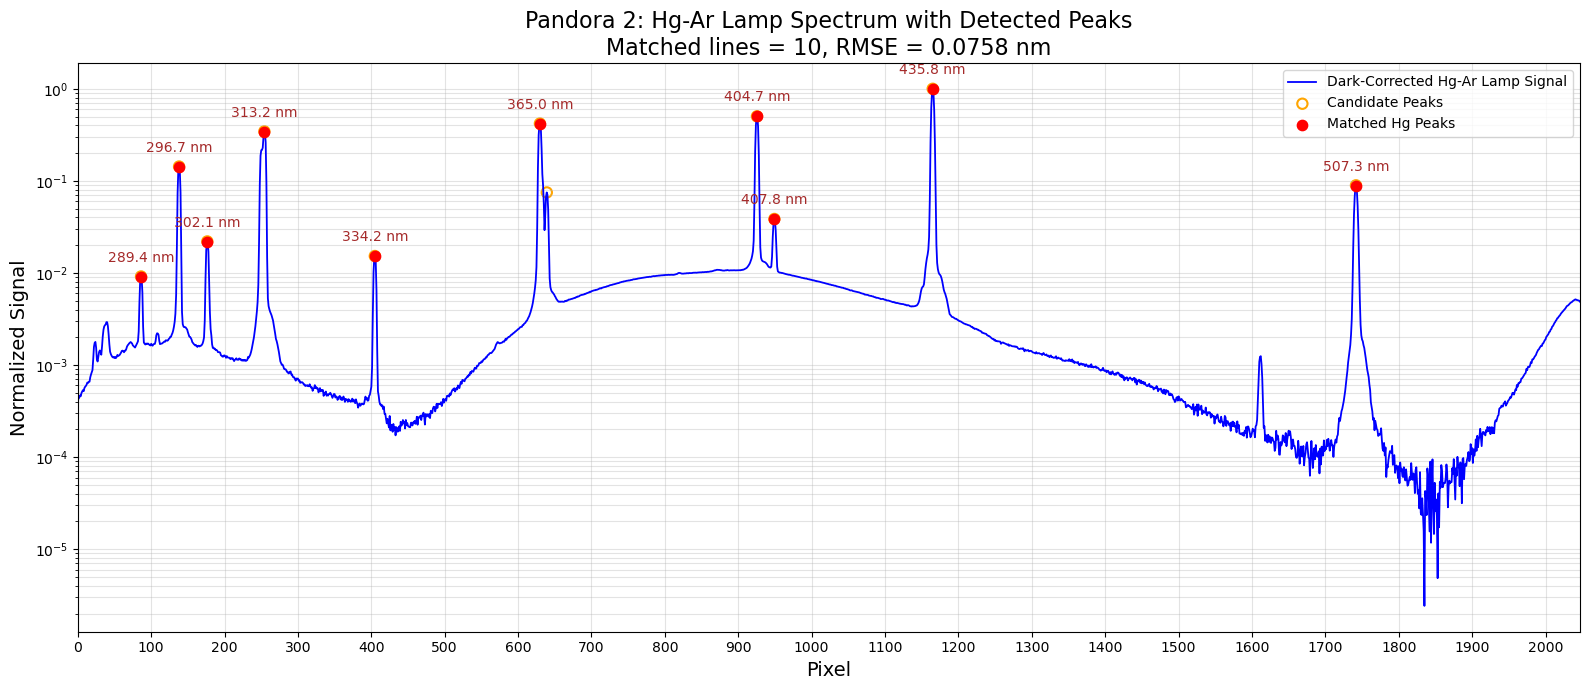

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.signal import find_peaks, peak_widths

# =========================================================
# SETTINGS
# =========================================================
known_lines_nm = np.array([289.36, 296.73, 302.15, 313.16, 334.19, 365.01, 404.66, 407.78, 435.84, 507.30, 546.08], dtype=float)
primary_lines_nm = np.array([313.16, 365.01, 404.66, 435.84], dtype=float)

npix = len(reference_hg_spectrum)
pixels = np.arange(npix, dtype=float)

prominence_fraction = 0.002
minimum_peak_distance = 8
minimum_peak_width = 1.0
maximum_peak_width = 80.0
maximum_candidate_peaks = 25

minimum_dispersion = 0.03
maximum_dispersion = 0.30

initial_match_tolerance_nm = 1.5
refined_match_tolerance_nm = 0.50

minimum_matched_lines = 5
minimum_wavelength_span_nm = 80.0
dispersion_polynomial_degree = 2
maximum_refinement_iterations = 4

pandora_name = "Pandora 2"


# =========================================================
# DETECT CANDIDATE PEAKS
# =========================================================
prominence_threshold = prominence_fraction * np.nanmax(reference_hg_spectrum)
detected_peaks, peak_properties = find_peaks(reference_hg_spectrum, prominence=prominence_threshold, distance=minimum_peak_distance)
detected_widths = peak_widths(reference_hg_spectrum, detected_peaks, rel_height=0.5)[0]

valid_peak_mask = (detected_widths >= minimum_peak_width) & (detected_widths <= maximum_peak_width)
detected_peaks = detected_peaks[valid_peak_mask]
detected_widths = detected_widths[valid_peak_mask]
detected_prominences = peak_properties["prominences"][valid_peak_mask]

if len(detected_peaks) == 0:
    raise RuntimeError("No valid Hg peak candidates were detected.")

# Keep the strongest candidate peaks if too many were detected
if len(detected_peaks) > maximum_candidate_peaks:
    strongest_indices = np.argsort(detected_prominences)[-maximum_candidate_peaks:]
    strongest_indices = strongest_indices[np.argsort(detected_peaks[strongest_indices])]
    detected_peaks = detected_peaks[strongest_indices]
    detected_widths = detected_widths[strongest_indices]
    detected_prominences = detected_prominences[strongest_indices]

# =========================================================
# REFINE PEAK CENTERS TO SUBPIXEL LOCATIONS
# =========================================================
candidate_pixels = []

for peak in detected_peaks:
    left = max(0, peak - 2)
    right = min(npix, peak + 3)
    x_local = np.arange(left, right, dtype=float)
    y_local = reference_hg_spectrum[left:right]

    if len(x_local) >= 3 and np.all(np.isfinite(y_local)):
        quadratic_coefficients = np.polyfit(x_local, y_local, 2)
        quadratic_a = quadratic_coefficients[0]
        quadratic_b = quadratic_coefficients[1]

        if quadratic_a < 0:
            refined_pixel = -quadratic_b / (2.0 * quadratic_a)

            if left <= refined_pixel <= right - 1:
                candidate_pixels.append(refined_pixel)
            else:
                candidate_pixels.append(float(peak))
        else:
            candidate_pixels.append(float(peak))
    else:
        candidate_pixels.append(float(peak))

candidate_pixels = np.array(candidate_pixels, dtype=float)
candidate_order = np.argsort(candidate_pixels)
candidate_pixels = candidate_pixels[candidate_order]
detected_peaks = detected_peaks[candidate_order]
detected_widths = detected_widths[candidate_order]
detected_prominences = detected_prominences[candidate_order]

candidate_quality = detected_prominences / np.nanmax(detected_prominences)
candidate_quality = np.clip(candidate_quality, 0.05, 1.0)

print(f"Detected candidate peaks: {len(candidate_pixels)}")
print("Candidate pixels:", np.round(candidate_pixels, 3))


# =========================================================
# GENERATE DISPERSION HYPOTHESES AND FIND BEST MATCH
# =========================================================
best_score = -np.inf
best_coefficients = None
best_matched_candidate_indices = None
best_matched_line_indices = None
best_rmse_nm = None

candidate_pairs = list(combinations(range(len(candidate_pixels)), 2))
line_pairs = list(combinations(range(len(known_lines_nm)), 2))

for candidate_index_1, candidate_index_2 in candidate_pairs:
    pixel_1 = candidate_pixels[candidate_index_1]
    pixel_2 = candidate_pixels[candidate_index_2]
    pixel_difference = pixel_2 - pixel_1

    if pixel_difference <= 0:
        continue

    for line_index_1, line_index_2 in line_pairs:
        wavelength_1 = known_lines_nm[line_index_1]
        wavelength_2 = known_lines_nm[line_index_2]
        slope = (wavelength_2 - wavelength_1) / pixel_difference

        if slope < minimum_dispersion or slope > maximum_dispersion:
            continue

        intercept = wavelength_1 - slope * pixel_1
        current_coefficients = np.array([slope, intercept], dtype=float)
        previous_assignment = None

        for refinement_iteration in range(maximum_refinement_iterations):
            predicted_candidate_wavelengths = np.polyval(current_coefficients, candidate_pixels)
            tolerance_nm = initial_match_tolerance_nm if refinement_iteration == 0 else refined_match_tolerance_nm

            possible_matches = []

            for candidate_index, predicted_wavelength in enumerate(predicted_candidate_wavelengths):
                wavelength_residuals = np.abs(known_lines_nm - predicted_wavelength)
                nearest_line_index = int(np.argmin(wavelength_residuals))
                nearest_residual = float(wavelength_residuals[nearest_line_index])

                if nearest_residual <= tolerance_nm:
                    possible_matches.append((nearest_residual, candidate_index, nearest_line_index))

            possible_matches.sort(key=lambda item: item[0])
            selected_candidate_indices = []
            selected_line_indices = []

            for residual_nm, candidate_index, line_index in possible_matches:
                if candidate_index in selected_candidate_indices or line_index in selected_line_indices:
                    continue

                selected_candidate_indices.append(candidate_index)
                selected_line_indices.append(line_index)

            if len(selected_candidate_indices) < minimum_matched_lines:
                break

            selected_candidate_indices = np.array(selected_candidate_indices, dtype=int)
            selected_line_indices = np.array(selected_line_indices, dtype=int)
            selected_order = np.argsort(selected_candidate_indices)
            selected_candidate_indices = selected_candidate_indices[selected_order]
            selected_line_indices = selected_line_indices[selected_order]

            if np.any(np.diff(selected_line_indices) <= 0):
                break

            matched_pixels = candidate_pixels[selected_candidate_indices]
            matched_wavelengths = known_lines_nm[selected_line_indices]
            matched_weights = np.sqrt(candidate_quality[selected_candidate_indices])

            actual_degree = min(dispersion_polynomial_degree, len(matched_pixels) - 1)
            new_coefficients = np.polyfit(matched_pixels, matched_wavelengths, actual_degree, w=matched_weights)

            test_pixels = np.linspace(0, npix - 1, 500)
            dispersion_derivative = np.polyval(np.polyder(new_coefficients), test_pixels)

            if np.any(dispersion_derivative <= 0):
                break

            current_assignment = tuple(zip(selected_candidate_indices.tolist(), selected_line_indices.tolist()))
            current_coefficients = new_coefficients

            if current_assignment == previous_assignment:
                break

            previous_assignment = current_assignment

        if previous_assignment is None:
            continue

        predicted_candidate_wavelengths = np.polyval(current_coefficients, candidate_pixels)
        possible_matches = []

        for candidate_index, predicted_wavelength in enumerate(predicted_candidate_wavelengths):
            wavelength_residuals = np.abs(known_lines_nm - predicted_wavelength)
            nearest_line_index = int(np.argmin(wavelength_residuals))
            nearest_residual = float(wavelength_residuals[nearest_line_index])

            if nearest_residual <= refined_match_tolerance_nm:
                possible_matches.append((nearest_residual, candidate_index, nearest_line_index))

        possible_matches.sort(key=lambda item: item[0])
        selected_candidate_indices = []
        selected_line_indices = []

        for residual_nm, candidate_index, line_index in possible_matches:
            if candidate_index in selected_candidate_indices or line_index in selected_line_indices:
                continue

            selected_candidate_indices.append(candidate_index)
            selected_line_indices.append(line_index)

        if len(selected_candidate_indices) < minimum_matched_lines:
            continue

        selected_candidate_indices = np.array(selected_candidate_indices, dtype=int)
        selected_line_indices = np.array(selected_line_indices, dtype=int)
        selected_order = np.argsort(selected_candidate_indices)
        selected_candidate_indices = selected_candidate_indices[selected_order]
        selected_line_indices = selected_line_indices[selected_order]

        if np.any(np.diff(selected_line_indices) <= 0):
            continue

        matched_pixels = candidate_pixels[selected_candidate_indices]
        matched_wavelengths = known_lines_nm[selected_line_indices]
        wavelength_span_nm = np.max(matched_wavelengths) - np.min(matched_wavelengths)

        if wavelength_span_nm < minimum_wavelength_span_nm:
            continue

        matched_weights = np.sqrt(candidate_quality[selected_candidate_indices])
        actual_degree = min(dispersion_polynomial_degree, len(matched_pixels) - 1)
        final_coefficients = np.polyfit(matched_pixels, matched_wavelengths, actual_degree, w=matched_weights)
        fitted_matched_wavelengths = np.polyval(final_coefficients, matched_pixels)
        residuals_nm = matched_wavelengths - fitted_matched_wavelengths
        rmse_nm = np.sqrt(np.mean(residuals_nm ** 2))
        maximum_residual_nm = np.max(np.abs(residuals_nm))

        test_pixels = np.linspace(0, npix - 1, 500)
        dispersion_derivative = np.polyval(np.polyder(final_coefficients), test_pixels)

        if np.any(dispersion_derivative <= 0):
            continue

        matched_primary_lines = np.sum([np.any(np.isclose(wavelength, primary_lines_nm, atol=0.02)) for wavelength in matched_wavelengths])
        pixel_span = np.max(matched_pixels) - np.min(matched_pixels)
        unmatched_candidate_count = len(candidate_pixels) - len(matched_pixels)
        score = 15.0 * len(matched_pixels) + 4.0 * matched_primary_lines + 0.03 * wavelength_span_nm + 0.002 * pixel_span - 12.0 * rmse_nm - 3.0 * maximum_residual_nm - 0.10 * unmatched_candidate_count

        if score > best_score:
            best_score = score
            best_coefficients = final_coefficients.copy()
            best_matched_candidate_indices = selected_candidate_indices.copy()
            best_matched_line_indices = selected_line_indices.copy()
            best_rmse_nm = rmse_nm


# =========================================================
# CHECK FINAL RESULT
# =========================================================
if best_coefficients is None:
    raise RuntimeError("No reliable Hg-line assignment was found. Try reducing prominence_fraction or increasing initial_match_tolerance_nm.")

matched_pixels = candidate_pixels[best_matched_candidate_indices]
matched_wavelengths = known_lines_nm[best_matched_line_indices]
fitted_matched_wavelengths = np.polyval(best_coefficients, matched_pixels)
matched_residuals_nm = matched_wavelengths - fitted_matched_wavelengths
matched_local_dispersion = np.polyval(np.polyder(best_coefficients), matched_pixels)
matched_residuals_pixels = matched_residuals_nm / matched_local_dispersion

wavelengths_fitted = np.polyval(best_coefficients, pixels)
wavelength_min = wavelengths_fitted[0]
wavelength_max = wavelengths_fitted[-1]

print("\n========================================")
print("FINAL HG MATCHING RESULT")
print("========================================")
print(f"Matched lines: {len(matched_pixels)}")
print(f"RMSE: {best_rmse_nm:.6f} nm")
print(f"Estimated wavelength range: {wavelength_min:.2f} to {wavelength_max:.2f} nm")
print("Dispersion coefficients:", best_coefficients)

print("\nMatched Hg lines:")
print("Hg wavelength     Pixel       Residual (nm)    Residual (pixel)")

for wavelength, pixel, residual_nm, residual_pixel in zip(matched_wavelengths, matched_pixels, matched_residuals_nm, matched_residuals_pixels):
    print(f"{wavelength:10.2f} nm   {pixel:9.3f}   {residual_nm:13.6f}   {residual_pixel:16.4f}")

print("\nAll known Hg-line statuses:")

for wavelength in known_lines_nm:
    matching_position = np.where(np.isclose(matched_wavelengths, wavelength, atol=0.01))[0]

    if len(matching_position) > 0:
        matching_index = matching_position[0]
        print(f"{wavelength:7.2f} nm: matched at pixel {matched_pixels[matching_index]:.3f}")
    elif wavelength < wavelength_min:
        print(f"{wavelength:7.2f} nm: outside low-wavelength range")
    elif wavelength > wavelength_max:
        print(f"{wavelength:7.2f} nm: outside high-wavelength range")
    else:
        predicted_pixel = np.interp(wavelength, wavelengths_fitted, pixels)
        print(f"{wavelength:7.2f} nm: inside range but not detected, predicted pixel {predicted_pixel:.3f}")


# =========================================================
# PLOT RESULT
# =========================================================
positive_signal = reference_hg_spectrum[reference_hg_spectrum > 0]
plot_floor = max(np.min(positive_signal) * 0.5, 1e-8)
plot_spectrum = np.clip(reference_hg_spectrum, plot_floor, None)

plt.figure(figsize=(16, 7))
plt.plot(pixels, plot_spectrum, color="blue", linewidth=1.3, label="Dark-Corrected Hg-Ar Lamp Signal")
plt.scatter(candidate_pixels, plot_spectrum[detected_peaks], facecolors="none", edgecolors="orange", s=55, linewidths=1.5, label="Candidate Peaks")
plt.scatter(matched_pixels, np.interp(matched_pixels, pixels, plot_spectrum), color="red", s=55, label="Matched Hg Peaks", zorder=5)

for pixel, wavelength in zip(matched_pixels, matched_wavelengths):
    peak_signal = np.interp(pixel, pixels, plot_spectrum)
    plt.text(pixel, peak_signal * 1.35, f"{wavelength:.1f} nm", color="brown", fontsize=10, ha="center", va="bottom")

plt.yscale("log")
plt.xlim(0, npix - 1)
plt.xticks(np.arange(0, npix + 1, 100))
plt.xlabel("Pixel", fontsize=14)
plt.ylabel("Normalized Signal", fontsize=14)
plt.title(f"{pandora_name}: Hg-Ar Lamp Spectrum with Detected Peaks\nMatched lines = {len(matched_pixels)}, RMSE = {best_rmse_nm:.4f} nm", fontsize=16)
plt.legend()
plt.grid(True, which="both", alpha=0.35)
plt.tight_layout()
plt.show()

# 3. Load Measured Spectrum

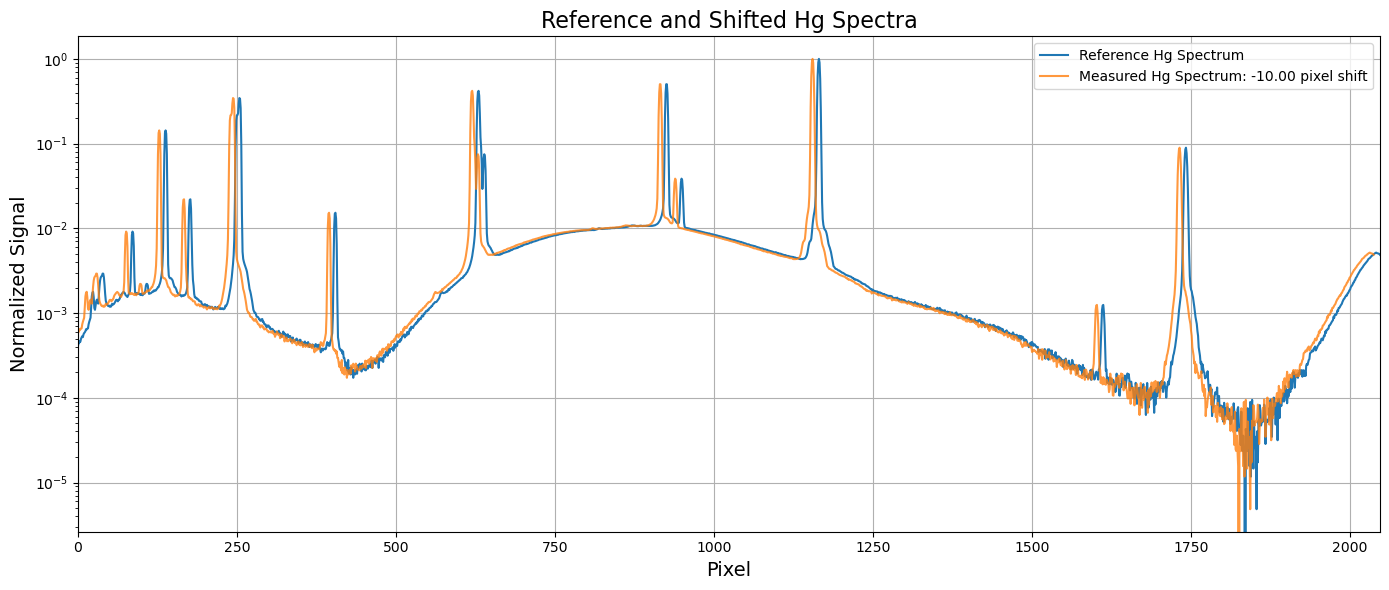

In [10]:
# A simulated spectrum is created here

pixel_shift = -10
pixels = np.arange(len(reference_hg_spectrum), dtype=float)
measured_hg_spectrum = np.interp(pixels - pixel_shift, pixels, reference_hg_spectrum, left=np.nan, right=np.nan)

plt.figure(figsize=(14, 6))
plt.yscale("log")
plt.plot(pixels, reference_hg_spectrum, label="Reference Hg Spectrum")
plt.plot(pixels, measured_hg_spectrum, label=f"Measured Hg Spectrum: {pixel_shift:+.2f} pixel shift", alpha=0.8)
plt.xlabel("Pixel", fontsize=14)
plt.ylabel("Normalized Signal", fontsize=14)
plt.title("Reference and Shifted Hg Spectra", fontsize=16)
plt.xlim(0, len(reference_hg_spectrum) - 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Calculate Spectrum shift in pixels

In [11]:
from scipy.signal import correlate, correlation_lags
import numpy as np


def calculate_pixel_shift(reference_spectrum, measured_spectrum, minimum_shift_pixels=-100, maximum_shift_pixels=100):
    """
    Calculate the pixel shift between two spectra using cross-correlation.

    Parameters
    ----------
    reference_spectrum : array-like
        Reference spectrum.

    measured_spectrum : array-like
        Measured spectrum to compare with the reference.

    minimum_shift_pixels : int, optional
        Minimum pixel shift to search.

    maximum_shift_pixels : int, optional
        Maximum pixel shift to search.

    Returns
    -------
    shift_pixels : float
        Estimated subpixel shift. A positive value means the measured
        spectrum is shifted toward larger pixel numbers relative to
        the reference spectrum.
    """

    reference = np.asarray(reference_spectrum, dtype=float)
    measured = np.asarray(measured_spectrum, dtype=float)

    valid_mask = np.isfinite(reference) & np.isfinite(measured)
    reference = reference[valid_mask]
    measured = measured[valid_mask]

    reference = reference - np.mean(reference)
    measured = measured - np.mean(measured)

    reference = reference / np.std(reference)
    measured = measured / np.std(measured)

    correlation = correlate(measured, reference, mode="full", method="fft")
    lags = correlation_lags(len(measured), len(reference), mode="full")

    shift_mask = (lags >= minimum_shift_pixels) & (lags <= maximum_shift_pixels)
    correlation_search = correlation[shift_mask]
    lags_search = lags[shift_mask]

    best_index = np.argmax(correlation_search)
    integer_shift_pixels = lags_search[best_index]

    shift_pixels = float(integer_shift_pixels)

    if 0 < best_index < len(correlation_search) - 1:
        y1 = correlation_search[best_index - 1]
        y2 = correlation_search[best_index]
        y3 = correlation_search[best_index + 1]

        denominator = y1 - 2.0 * y2 + y3

        if abs(denominator) > 1e-12:
            subpixel_offset = 0.5 * (y1 - y3) / denominator
            shift_pixels = integer_shift_pixels + subpixel_offset

    return shift_pixels

shift = calculate_pixel_shift(
    reference_hg_spectrum,
    measured_hg_spectrum,
    minimum_shift_pixels=-100,
    maximum_shift_pixels=100
)

print(f"Pixel shift = {shift:+.4f}")

Pixel shift = -9.9999


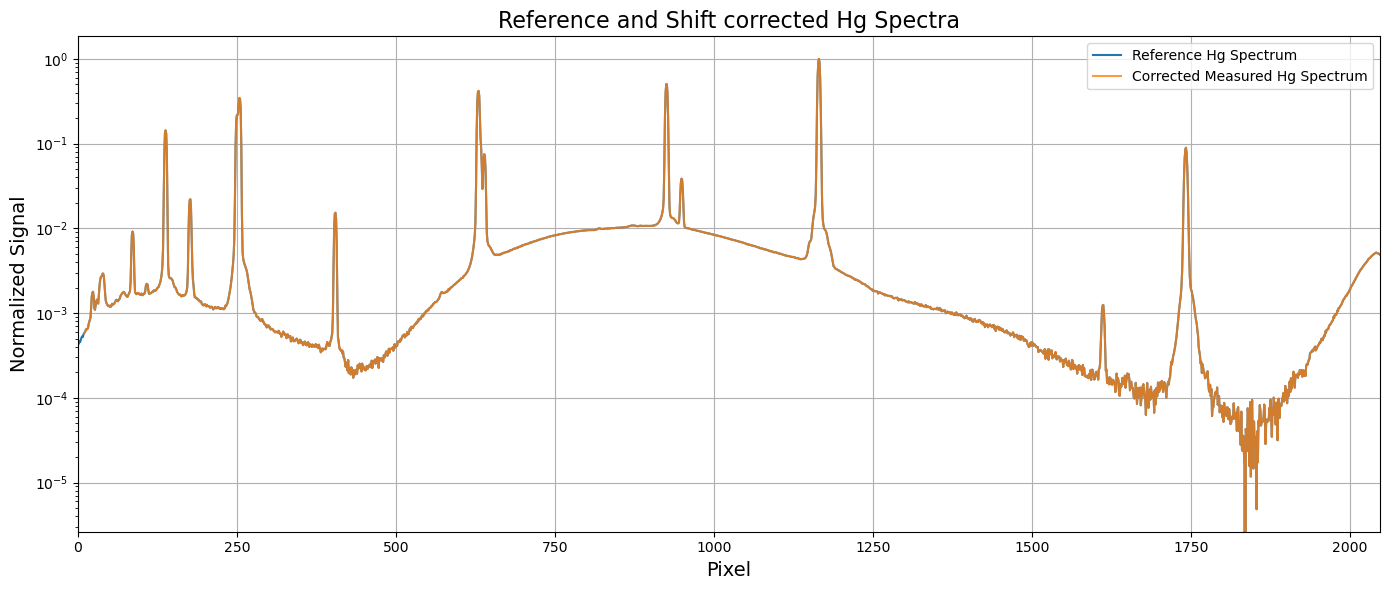

In [13]:
plt.figure(figsize=(14, 6))
plt.yscale("log")
plt.plot(pixels, reference_hg_spectrum, label="Reference Hg Spectrum")
plt.plot(pixels-shift, measured_hg_spectrum, label="Corrected Measured Hg Spectrum", alpha=0.8)
plt.xlabel("Pixel", fontsize=14)
plt.ylabel("Normalized Signal", fontsize=14)
plt.title("Reference and Shift corrected Hg Spectra", fontsize=16)
plt.xlim(0, len(reference_hg_spectrum) - 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Test 2: Large Shift (Pandora 63)

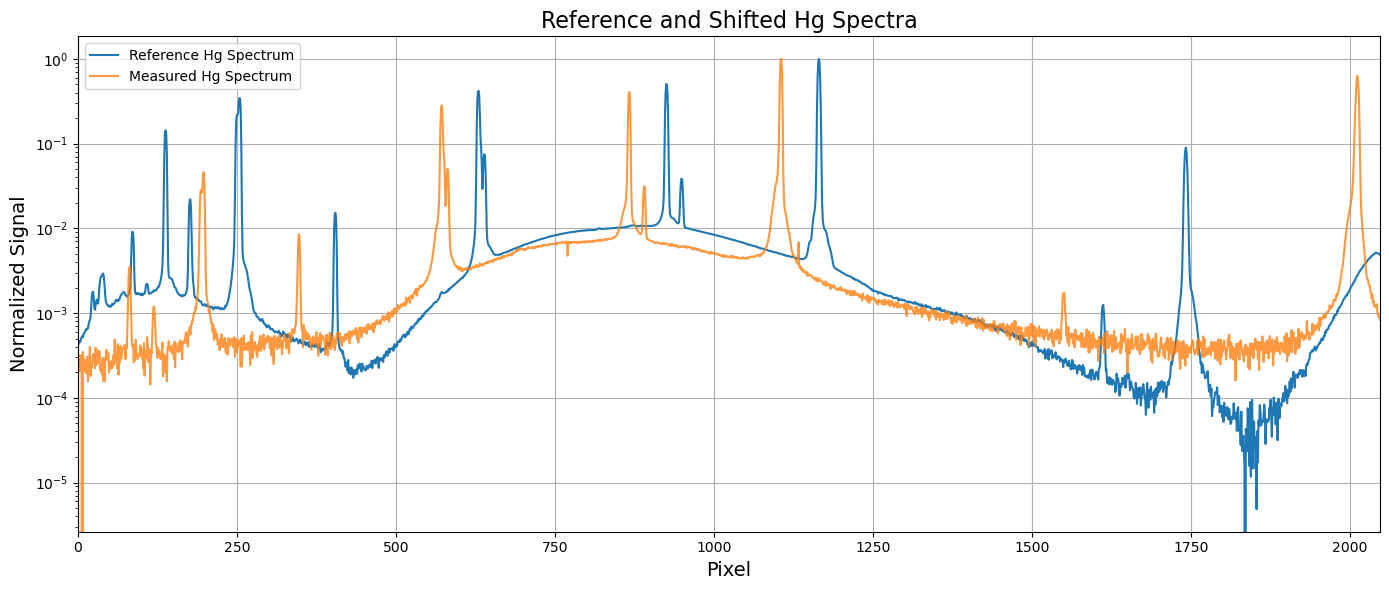

In [6]:
file_path = r'C:\Users\sciglob\OneDrive - UMBC\4. SciGlob\Panndora_456\Lab_pandora\25_Sept_4_pandora63\Pandora63s1_LabGSFC_20250311_L0.txt'

base_name = os.path.basename(file_path)
csv_file_name = os.path.splitext(base_name)[0] + '.csv'

# Read the entire file
with open(file_path, 'r', encoding='latin1') as file:
    lines = file.readlines()

data_lines = lines[44:]

# Process each line to split into rows and columns
data_list = []
for line in data_lines:
    # Strip the newline character and split by tabs
    rows = line.strip().split('\t')
    for row in rows:
        # Split each row by spaces
        columns = row.split()
        data_list.append(columns)

# Convert the list of lists into a DataFrame
data2 = pd.DataFrame(data_list)
# Convert the necessary columns to numeric before saving
data2.iloc[:, 2:] = data2.iloc[:, 2:].apply(pd.to_numeric, errors='coerce')

lsf_hg_BC_P63 = pd.to_numeric(data2.iloc[124, 24:2072], errors="coerce").to_numpy(dtype=float) / float(data2.iloc[124, 22])
lsf_hg_DC_P63 = pd.to_numeric(data2.iloc[125, 24:2072], errors="coerce").to_numpy(dtype=float) / float(data2.iloc[125, 22])

hg_spectrum_P63 = lsf_hg_BC_P63 - lsf_hg_DC_P63
measured_hg_spectrum = normalize(hg_spectrum_P63)

plt.figure(figsize=(14, 6))
plt.yscale("log")
plt.plot(pixels, reference_hg_spectrum, label="Reference Hg Spectrum")
plt.plot(pixels, measured_hg_spectrum, label="Measured Hg Spectrum", alpha=0.8)
plt.xlabel("Pixel", fontsize=14)
plt.ylabel("Normalized Signal", fontsize=14)
plt.title("Reference and Shifted Hg Spectra", fontsize=16)
plt.xlim(0, len(reference_hg_spectrum) - 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
shift = calculate_pixel_shift(
    reference_hg_spectrum,
    measured_hg_spectrum,
    minimum_shift_pixels=-100,
    maximum_shift_pixels=100
)

print(f"Pixel shift = {shift:+.4f}")

Pixel shift = -59.2802


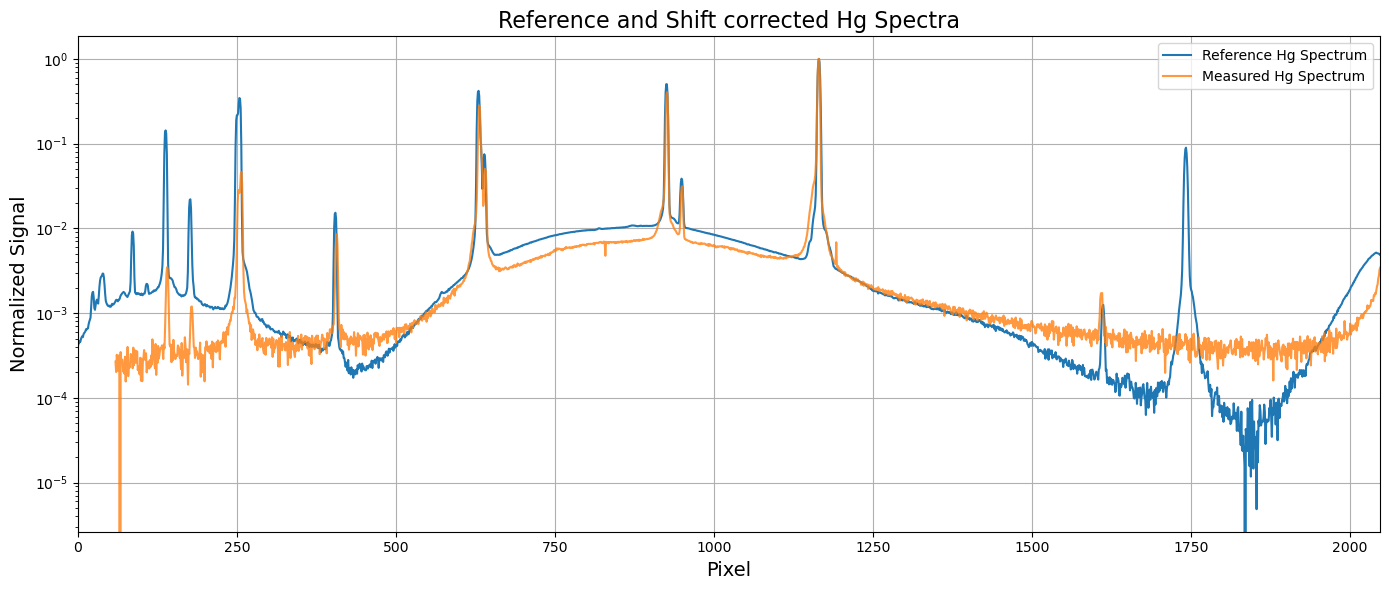

In [9]:
plt.figure(figsize=(14, 6))
plt.yscale("log")
plt.plot(pixels, reference_hg_spectrum, label="Reference Hg Spectrum")
plt.plot(pixels-shift, measured_hg_spectrum, label="Corrected Measured Hg Spectrum", alpha=0.8)
plt.xlabel("Pixel", fontsize=14)
plt.ylabel("Normalized Signal", fontsize=14)
plt.title("Reference and Shift corrected Hg Spectra", fontsize=16)
plt.xlim(0, len(reference_hg_spectrum) - 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()